In [2]:
from huggingface_hub import snapshot_download
import os

local_dir = "/kaggle/working/lettuce_model"

os.makedirs(local_dir, exist_ok=True)


download_path = snapshot_download(
    repo_id="Sanbei101/lettuce",
    local_dir=local_dir,
)

print(f"模型已下载到: {download_path}")

import subprocess
result = subprocess.run(["ls", "-lh", local_dir], capture_output=True, text=True)
print(result.stdout)

Fetching 200 files:   0%|          | 0/200 [00:00<?, ?it/s]

模型已下载到: /kaggle/working/lettuce_model
total 53M
-rw-r--r-- 1 root root  52M Mar 16 12:31 best.pt
-rw-r--r-- 1 root root  258 Mar 16 12:31 data.yaml
-rw-r--r-- 1 root root 7.5K Mar 16 12:31 lettuce_data.json
-rw-r--r-- 1 root root   24 Mar 16 12:31 README.md
-rw-r--r-- 1 root root 609K Mar 16 12:31 rf_weight_model.pkl
drwxr-xr-x 4 root root 4.0K Mar 16 12:31 test
drwxr-xr-x 4 root root 4.0K Mar 16 12:35 train
drwxr-xr-x 4 root root 4.0K Mar 16 12:35 valid



In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.6 MB/s eta 0:00:00


选用yolo26进行图形的切分,供后期进行像素点计算

In [9]:
import os
from ultralytics import YOLO


model = YOLO('yolo26m-seg.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [10]:
print("开始训练分割模型...")

results = model.train(
    data='/kaggle/working/lettuce_model/data.yaml',
    epochs=20,             # 训练的总轮数
    imgsz=640,             # 图像尺寸,已经处理好了 640
    batch=16,              # 批次大小
    workers=4,             # 数据加载的线程数
    device='0',            # 使用显卡
    exist_ok=True          # 允许覆盖同名文件夹
)

开始训练分割模型...
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/lettuce_model/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mas

In [11]:
# 评估模型性能
metrics = model.val()

print(f"验证集分割 mAP50: {metrics.seg.map50:.4f}")
print(f"验证集分割 mAP50-95: {metrics.seg.map:.4f}")

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO26m-seg summary (fused): 149 layers, 23,508,239 parameters, 0 gradients, 121.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 612.4±174.8 MB/s, size: 16.2 KB)
val: Scanning /kaggle/working/lettuce_model/valid/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 1.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 4.8it/s 0.2s
                   all          5          5       0.99          1      0.995      0.948       0.99          1      0.995       0.93
Speed: 1.0ms preprocess, 22.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /kaggle/working/runs/segment/val
验证集分割 mAP50: 0.9950
验证集分割 mAP50-95: 0.9297


开始推理并保存结果...

image 1/1 /kaggle/working/lettuce_model/test/images/3-10_jpg.rf.8b9f1190192b20ec69ce6e20c78ce33c.jpg: 640x640 1 lettuce, 23.7ms
Speed: 1.8ms preprocess, 23.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/segment/predict4

预测完成！结果已保存在: /kaggle/working/runs/segment/predict4/3-10_jpg.rf.8b9f1190192b20ec69ce6e20c78ce33c.jpg
预测效果图如下：


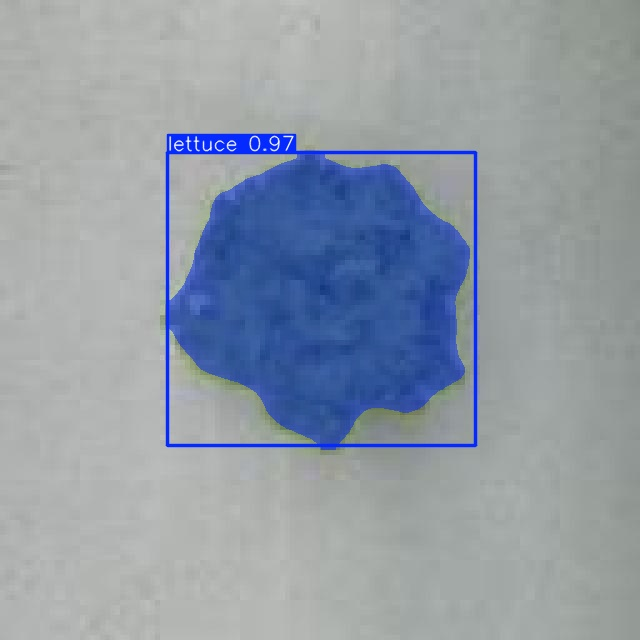

In [6]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

model_path = '/kaggle/working/runs/segment/train/weights/best.pt'
model = YOLO(model_path)

test_image_path = '/kaggle/working/lettuce_model/test/images/3-10_jpg.rf.8b9f1190192b20ec69ce6e20c78ce33c.jpg' 

if os.path.exists(test_image_path):
    print("开始推理并保存结果...")
    
    predict_results = model.predict(
        source=test_image_path,
        conf=0.25,
        save=True
    )
    
    result = predict_results[0]
    
    image_filename = os.path.basename(test_image_path)
    
    saved_image_path = os.path.join(result.save_dir, image_filename)
    
    print(f"\n预测完成！结果已保存在: {saved_image_path}")
    print("预测效果图如下：")
    
    display(Image(filename=saved_image_path, width=600))
    
else:
    print(f"警告: 找不到测试图片 {test_image_path},请修改代码中的文件名")

In [14]:
!hf auth login
!hf upload Sanbei101/lettuce /kaggle/working/lettuce_model .

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `123324` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `123324`
It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.
Start hashing 197 files.
Finished hashing 197 files.
Processing Files (0 / 0)      : |                  |  0.00B /  0.00B            
New Data Upload               : |   